## 🧠 What is Gradient Descent?

Gradient Descent is an optimization algorithm used to minimize error.

### Formula:
w = w - α * (∂J/∂w)

- w = weight
- α = learning rate
- J = cost function

In [1]:
# Import Library
import numpy as np
import matplotlib.pyplot as plt

## 📊 Dataset

In [2]:
X = np.array([2,4,6,8,10,12,14,16,18,20])
Y = np.array([10,20,30,40,50,60,70,80,90,100])

## ⚙️ Gradient Descent Function

In [3]:
def gradient_descent(x, y):
    m = 0
    c = 0
    rate = 0.001
    iteration = 100
    n = len(x)

    for i in range(iteration):
        y_predicted = m * x + c
        cost = (1/n) * sum([val**2 for val in (y - y_predicted)])

        mp = -(2/n) * sum(x * (y - y_predicted))
        cp = -(2/n) * sum(y - y_predicted)

        m = m - rate * mp
        c = c - rate * cp

        plt.scatter(X, Y)
        plt.plot(X, y_predicted, color='red')

        print(f"Iteration {i+1}: m={m:.4f}, c={c:.4f}, cost={cost:.4f}")

    return m, c

## ▶️ Run Gradient Descent

Iteration 1: m=1.5400, c=0.1100, cost=3850.0000
Iteration 2: m=2.6033, c=0.1859, cost=1835.2653
Iteration 3: m=3.3374, c=0.2383, cost=874.8642
Iteration 4: m=3.8442, c=0.2744, cost=417.0520
Iteration 5: m=4.1942, c=0.2992, cost=198.8181
Iteration 6: m=4.4358, c=0.3164, cost=94.7884
Iteration 7: m=4.6026, c=0.3281, cost=45.1987
Iteration 8: m=4.7178, c=0.3362, cost=21.5598
Iteration 9: m=4.7973, c=0.3418, cost=10.2914
Iteration 10: m=4.8522, c=0.3455, cost=4.9199
Iteration 11: m=4.8901, c=0.3481, cost=2.3593
Iteration 12: m=4.9163, c=0.3498, cost=1.1387
Iteration 13: m=4.9344, c=0.3510, cost=0.5569
Iteration 14: m=4.9469, c=0.3517, cost=0.2795
Iteration 15: m=4.9555, c=0.3522, cost=0.1472
Iteration 16: m=4.9615, c=0.3524, cost=0.0842
Iteration 17: m=4.9656, c=0.3526, cost=0.0541
Iteration 18: m=4.9684, c=0.3526, cost=0.0398
Iteration 19: m=4.9704, c=0.3526, cost=0.0329
Iteration 20: m=4.9718, c=0.3526, cost=0.0297
Iteration 21: m=4.9727, c=0.3525, cost=0.0281
Iteration 22: m=4.9734, c=0

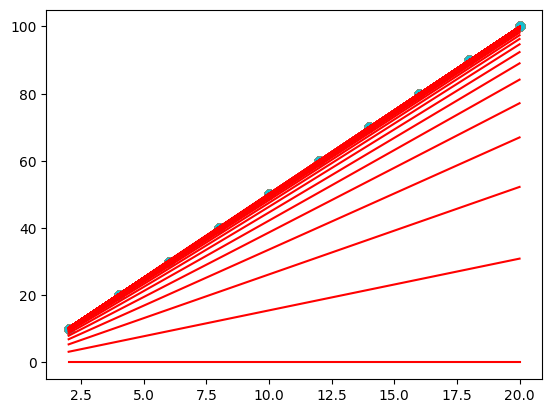

In [4]:
m, c = gradient_descent(X, Y)

In [5]:
from sklearn.linear_model import LinearRegression


In [6]:
lr = LinearRegression()

In [7]:
lr.fit(X.reshape(-1, 1), Y)

LinearRegression()

In [8]:
lr.coef_

array([5.])

In [9]:
lr.intercept_

np.float64(-2.1316282072803006e-14)

## 🧠 What is Stochastic Gradient Descent (SGD)?

Stochastic Gradient Descent (SGD) is a variant of Gradient Descent. Unlike Batch Gradient Descent, which calculates the gradient over the entire dataset for each update, SGD updates the model parameters (weights `m` and bias `c`) after processing *each individual data point*.

This makes SGD much faster for large datasets, as it doesn't need to load the entire dataset into memory for each update. However, the updates are more 'noisy' due to the high variance of the individual gradients, which can cause the cost function to fluctuate instead of smoothly decreasing. Despite this, SGD often converges faster to a good solution.

### Key Differences:
-   **Batch Gradient Descent**: Uses all data points to compute gradient for one update.
-   **Stochastic Gradient Descent**: Uses one randomly chosen data point to compute gradient for one update.

In [10]:
import random

def stochastic_gradient_descent(x, y, rate=0.001, epochs=100):
    m = 0
    c = 0
    n = len(x)

    plt.figure(figsize=(10, 6))

    for epoch in range(epochs):
        # Shuffle data indices for each epoch to ensure randomness
        data_indices = list(range(n))  # [0, 1, 2, 3, ..., 99] => [45, 20, 35, ...., 48]
        random.shuffle(data_indices)

        for i in data_indices:
            x_i = x[i]
            y_i = y[i]

            y_predicted_i = m * x_i + c

            # Calculate gradients for a single data point
            mp_i = -2 * x_i * (y_i - y_predicted_i)
            cp_i = -2 * (y_i - y_predicted_i)

            # Update m and c using the gradient from this single data point
            m = m - rate * mp_i
            c = c - rate * cp_i

        # After each epoch, calculate the cost over the entire dataset for monitoring
        y_predicted = m * x + c
        cost = (1/n) * sum([val**2 for val in (y - y_predicted)])
        print(f"Epoch {epoch+1}: m={m:.4f}, c={c:.4f}, cost={cost:.4f}")

        # Plot the current regression line for each epoch to visualize progress
        plt.scatter(X, Y, color='blue', label='Data Points' if epoch == 0 else "")
        plt.plot(X, y_predicted, color='green', alpha=0.2, label='Intermediate Fits' if epoch == 0 else "")

    # Plot the final best fit line
    plt.plot(X, y_predicted, color='red', linewidth=2, label='Final SGD Fit')
    plt.title('Stochastic Gradient Descent Progress')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.show()

    return m, c

## ▶️ Run Stochastic Gradient Descent

Epoch 1: m=4.9345, c=0.3371, cost=0.2882
Epoch 2: m=4.9756, c=0.3389, cost=0.0246
Epoch 3: m=4.9768, c=0.3374, cost=0.0245
Epoch 4: m=4.9781, c=0.3360, cost=0.0249
Epoch 5: m=4.9819, c=0.3348, cost=0.0292
Epoch 6: m=4.9738, c=0.3327, cost=0.0246
Epoch 7: m=4.9775, c=0.3314, cost=0.0237
Epoch 8: m=4.9793, c=0.3301, cost=0.0246
Epoch 9: m=4.9782, c=0.3285, cost=0.0236
Epoch 10: m=4.9752, c=0.3269, cost=0.0232
Epoch 11: m=4.9782, c=0.3256, cost=0.0231
Epoch 12: m=4.9744, c=0.3239, cost=0.0234
Epoch 13: m=4.9825, c=0.3231, cost=0.0272
Epoch 14: m=4.9792, c=0.3214, cost=0.0229
Epoch 15: m=4.9793, c=0.3199, cost=0.0227
Epoch 16: m=4.9779, c=0.3184, cost=0.0218
Epoch 17: m=4.9740, c=0.3168, cost=0.0232
Epoch 18: m=4.9771, c=0.3155, cost=0.0213
Epoch 19: m=4.9779, c=0.3141, cost=0.0212
Epoch 20: m=4.9773, c=0.3127, cost=0.0210
Epoch 21: m=4.9747, c=0.3112, cost=0.0222
Epoch 22: m=4.9785, c=0.3100, cost=0.0207
Epoch 23: m=4.9762, c=0.3085, cost=0.0209
Epoch 24: m=4.9805, c=0.3074, cost=0.0212
E

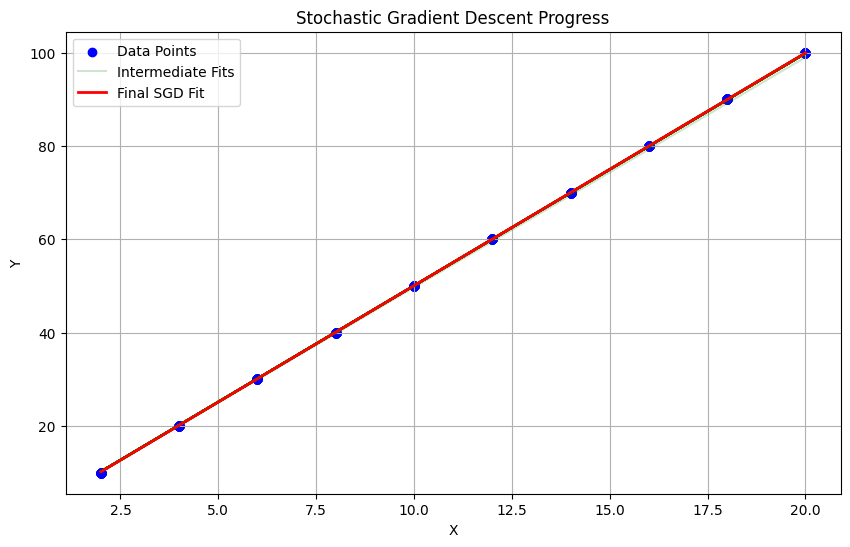


Final m (SGD): 4.9862
Final c (SGD): 0.2189


In [11]:
# Run SGD with the defined X and Y
m_sgd, c_sgd = stochastic_gradient_descent(X, Y, rate=0.001, epochs=100)

print(f"\nFinal m (SGD): {m_sgd:.4f}")
print(f"Final c (SGD): {c_sgd:.4f}")

## 🧠 What is Mini-Batch Gradient Descent?

Mini-Batch Gradient Descent is a training algorithm that combines the best aspects of both Batch Gradient Descent and Stochastic Gradient Descent.

### How it works:
1.  **Divide Data into Mini-Batches**: Instead of using the entire dataset (like Batch GD) or just one data point (like SGD) to calculate the gradient, Mini-Batch GD divides the dataset into smaller, fixed-size chunks called "mini-batches."
2.  **Calculate Gradient per Mini-Batch**: For each mini-batch, the model calculates the average gradient of the cost function with respect to the model parameters (weights `m` and bias `c`).
3.  **Update Parameters**: The model parameters are then updated using this average gradient and a learning rate. This process is repeated for every mini-batch in the dataset.
4.  **Repeat for Epochs**: This entire process (iterating through all mini-batches) is called an "epoch," and it's typically repeated for many epochs until the model converges.

### Key Advantages:
-   **Efficiency**: It's more computationally efficient than Stochastic Gradient Descent for large datasets because it processes more than one example at a time.
-   **Stability**: The updates are more stable than SGD because they are based on multiple examples, reducing the noise. However, it's still faster than Batch GD for large datasets.
-   **Convergence**: It often converges faster and more reliably than pure SGD, avoiding some of the erratic oscillations.

## ▶️ Demonstrate Mini-Batch Gradient Descent

Here's the practical demonstration using a code-alike structure for Mini-Batch Gradient Descent:


Starting Mini-Batch Gradient Descent with batch size: 4
Epoch 1: m=3.7901, c=0.2697, cost=218.3177
Epoch 2: m=4.5529, c=0.3212, cost=27.7243
Epoch 3: m=4.8283, c=0.3405, cost=3.3708
Epoch 4: m=4.9241, c=0.3468, cost=0.4288
Epoch 5: m=4.9548, c=0.3483, cost=0.0893
Epoch 6: m=4.9758, c=0.3493, cost=0.0262
Epoch 7: m=4.9742, c=0.3488, cost=0.0262
Epoch 8: m=4.9744, c=0.3484, cost=0.0261
Epoch 9: m=4.9733, c=0.3478, cost=0.0264
Epoch 10: m=4.9736, c=0.3474, cost=0.0263
Epoch 11: m=4.9759, c=0.3471, cost=0.0259
Epoch 12: m=4.9748, c=0.3466, cost=0.0258
Epoch 13: m=4.9757, c=0.3463, cost=0.0257
Epoch 14: m=4.9746, c=0.3457, cost=0.0257
Epoch 15: m=4.9764, c=0.3454, cost=0.0258
Epoch 16: m=4.9749, c=0.3448, cost=0.0255
Epoch 17: m=4.9762, c=0.3445, cost=0.0255
Epoch 18: m=4.9746, c=0.3440, cost=0.0255
Epoch 19: m=4.9744, c=0.3434, cost=0.0254
Epoch 20: m=4.9749, c=0.3431, cost=0.0253
Epoch 21: m=4.9741, c=0.3426, cost=0.0254
Epoch 22: m=4.9768, c=0.3423, cost=0.0253
Epoch 23: m=4.9773, c=0.34

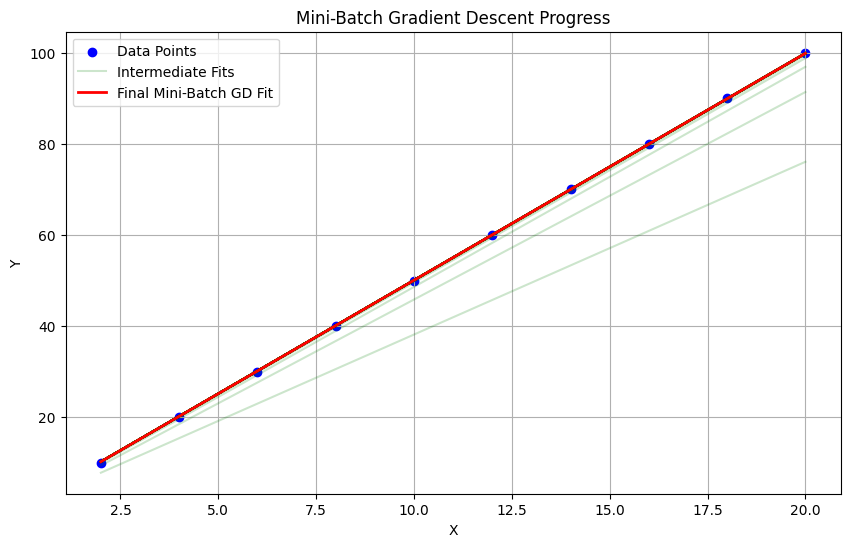


Final m (Mini-Batch GD): 4.9778
Final c (Mini-Batch GD): 0.3095


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random

def mini_batch_gradient_descent(x, y, learning_rate=0.001, num_epochs=100, batch_size=4):
    m = 0  # Initial slope
    c = 0  # Initial y-intercept
    n = len(x) # Total number of data points

    # Ensure batch size is not larger than the number of data points
    if batch_size > n:
        batch_size = n

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='blue', label='Data Points') # Plot original data points once

    print(f"Starting Mini-Batch Gradient Descent with batch size: {batch_size}")

    for epoch in range(num_epochs):
        # Shuffle the data indices for each epoch to create random mini-batches
        data_indices = list(range(n))
        random.shuffle(data_indices)

        # Iterate through mini-batches
        for i in range(0, n, batch_size):  # 3
            # Get the indices for the current mini-batch
            batch_indices = data_indices[i:i + batch_size]
            x_batch = x[batch_indices]
            y_batch = y[batch_indices]

            # Number of samples in the current mini-batch
            n_batch = len(x_batch)

            # Calculate predicted y for the current mini-batch
            y_predicted_batch = m * x_batch + c

            # Calculate gradients based on the current mini-batch
            # The gradient calculation is similar to Batch GD, but only for the batch data
            mp_batch = -(2 / n_batch) * np.sum(x_batch * (y_batch - y_predicted_batch))
            cp_batch = -(2 / n_batch) * np.sum(y_batch - y_predicted_batch)

            # Update m and c using the gradients from this mini-batch
            m = m - learning_rate * mp_batch
            c = c - learning_rate * cp_batch

        # After each epoch, calculate the cost over the entire dataset for monitoring
        # This provides a clearer picture of overall convergence
        y_predicted_full = m * x + c
        cost_full = (1 / n) * np.sum((y - y_predicted_full)**2)

        print(f"Epoch {epoch+1}: m={m:.4f}, c={c:.4f}, cost={cost_full:.4f}")

        # Plot the current regression line for each epoch to visualize progress
        # Using a slightly transparent line to show intermediate steps
        plt.plot(X, y_predicted_full, color='green', alpha=0.2, label='Intermediate Fits' if epoch == 0 else "")

    # Plot the final best fit line after all epochs
    plt.plot(X, y_predicted_full, color='red', linewidth=2, label='Final Mini-Batch GD Fit')
    plt.title('Mini-Batch Gradient Descent Progress')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.show()

    return m, c

# Run Mini-Batch Gradient Descent with the defined X and Y
# You can adjust learning_rate, num_epochs, and batch_size to see their effects
m_mbgd, c_mbgd = mini_batch_gradient_descent(X, Y, learning_rate=0.001, num_epochs=100, batch_size=4)

print(f"\nFinal m (Mini-Batch GD): {m_mbgd:.4f}")
print(f"Final c (Mini-Batch GD): {c_mbgd:.4f}")


### Code Explanation:

*   **`mini_batch_gradient_descent(x, y, ... , batch_size=4)`**: This is our function. The `batch_size` parameter is key, determining how many data points are processed at once.
*   **`random.shuffle(data_indices)`**: In each epoch, we shuffle the order of the data points. This ensures that our mini-batches are randomized across epochs, which helps in better convergence and prevents cycles.
*   **`for i in range(0, n, batch_size):`**: This loop iterates through the shuffled data, picking out `batch_size` number of data points at a time to form a mini-batch.
*   **`x_batch = x[batch_indices]` and `y_batch = y[batch_indices]`**: These lines select the `x` and `y` values for the current mini-batch.
*   **`mp_batch = -(2 / n_batch) * np.sum(x_batch * (y_batch - y_predicted_batch))`**: The gradients (`mp_batch` and `cp_batch`) are calculated using **only the data points within the current mini-batch** (`n_batch` is the size of the mini-batch). This is the core difference from Batch Gradient Descent (which uses `n` for the entire dataset) and Stochastic Gradient Descent (which uses `1` for a single data point).
*   **`m = m - learning_rate * mp_batch`**: The `m` and `c` values are updated after processing each mini-batch.

For more reference: [Watch this video](https://youtu.be/IU5fuoYBTAM)